In [ ]:
!pip install pennylane


In [1]:
from jax import numpy as np
import jax
jax.config.update("jax_platform_name", "cpu")
jax.config.update('jax_enable_x64', True)

import pennylane as qp


In [2]:
dataset=qp.data.load('qchem',molname="H2")[0]
H,qubits=dataset.hamiltonian,len(dataset.hamiltonian.wires)

In [3]:
dev=qp.device("lightning.qubit",wires=qubits)

In [4]:
electrons=2
hf=qp.qchem.hf_state(electrons,qubits)


In [13]:
@qp.qnode(dev,interface="jax")
def circuit(param,wires):
  qp.BasisState(hf,wires=wires)
  qp.DoubleExcitation(param,wires=[0,1,2,3])
  return qp.expval(H)

In [14]:
def cost_fn(param):
  return circuit(param,wires=range(qubits))

In [15]:
import optax
max_iterations=100
conv_tol=1e-06
opt=optax.sgd(learning_rate=0.4)

In [17]:
theta=np.array(0.)
energy=[cost_fn(theta)]
angle=[theta]
opt_state=opt.init(theta)
for n in range(max_iterations):
  gradient=jax.grad(cost_fn)(theta)
  updates,opt_state=opt.update(gradient,opt_state)
  theta=optax.apply_updates(theta,updates)

  angle.append(theta)
  energy.append(cost_fn(theta))

  conv=np.abs(energy[-1]-energy[-2])
  if conv<=conv_tol:
    break


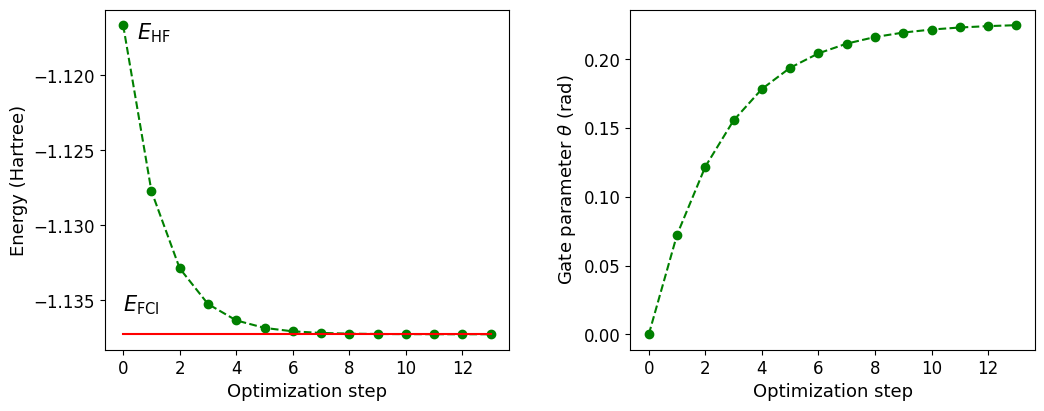

In [18]:
import matplotlib.pyplot as plt

fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(12)

# Full configuration interaction (FCI) energy computed classically
E_fci = dataset.fci_energy

# Add energy plot on column 1
ax1 = fig.add_subplot(121)
ax1.plot(range(n + 2), energy, "go", ls="dashed")
ax1.plot(range(n + 2), np.full(n + 2, E_fci), color="red")
ax1.set_xlabel("Optimization step", fontsize=13)
ax1.set_ylabel("Energy (Hartree)", fontsize=13)
ax1.text(0.5, -1.1176, r"$E_\mathrm{HF}$", fontsize=15)
ax1.text(0, -1.1357, r"$E_\mathrm{FCI}$", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add angle plot on column 2
ax2 = fig.add_subplot(122)
ax2.plot(range(n + 2), angle, "go", ls="dashed")
ax2.set_xlabel("Optimization step", fontsize=13)
ax2.set_ylabel("Gate parameter $\\theta$ (rad)", fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.subplots_adjust(wspace=0.3, bottom=0.2)
plt.show()
